# **Real** vs **Fake** face detection using Keras

This project aims to discriminate between **fake** images and **real** ones. This dataset consists of all 70k REAL faces from the Flickr dataset collected by Nvidia, as well as 70k fake faces sampled from the 1 Million FAKE faces (generated by StyleGAN) that was provided by Bojan.

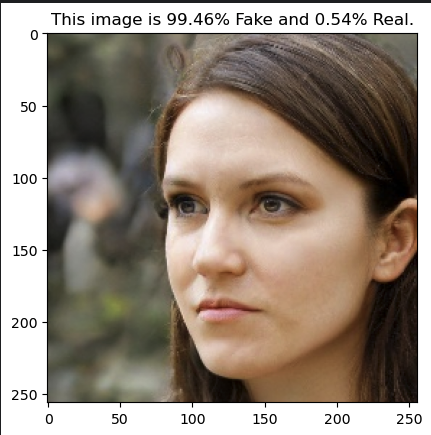

The project will include also the **Grad-cam** visualization to understand why a deep learning network makes its classification decisions.

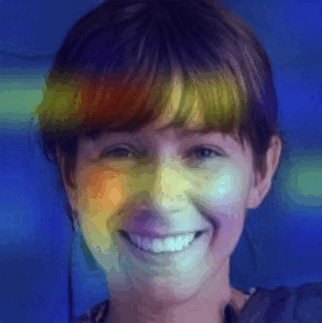

# Main Libraries

In [105]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import glob
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.models import load_model
from keras.preprocessing import image
import seaborn as sns
from sklearn import metrics

In [106]:
tf.keras.backend.clear_session() #clean session

# Data Loading

The paths to the training, validation, and test sets have been specified below.

In [107]:
main_path = '/kaggle/input/real-fake-22k/real-vs-fake10k'

train_dir = os.path.join(main_path, 'train')
valid_dir = os.path.join(main_path, 'valid')
test_dir = os.path.join(main_path, 'test')

As we can see, each directory contains two subfolders: fake and real.

In [108]:
print("Train_dir Subfolders: ", os.listdir(train_dir))
print("Valid_dir Subfolders: ", os.listdir(valid_dir))
print("Test_dir Subfolders: ", os.listdir(test_dir))

Train_dir Subfolders:  ['fake', 'real']
Valid_dir Subfolders:  ['fake', 'real']
Test_dir Subfolders:  ['fake', 'real']


# Short EDA - Exploratory Data Analysis

Create a dictionary with three keys:
* **folder**: train, validation and test folders
* **image_path**: path of the images
* **label**: image's label (fake or real)    

In [109]:
images_df = {
    "folder":[],
    "image_path":[],
    "label":[]
}

for folder in os.listdir(main_path): #iterate on each train, valid and test folder
    for label in os.listdir(main_path + "/" + folder): #iterate on fake and real folders (labels)
        for img in glob.glob(main_path + "/" + folder + "/" + label + "/*.jpg"):
            images_df["folder"].append(folder)
            images_df["image_path"].append(img)
            images_df["label"].append(label)

In [110]:
images_df = pd.DataFrame(images_df)

In [111]:
images_df

,folder,image_path,label
0,valid,/kaggle/input/real-fake-22k/real-vs-fake10k/va...,fake
1,valid,/kaggle/input/real-fake-22k/real-vs-fake10k/va...,fake
2,valid,/kaggle/input/real-fake-22k/real-vs-fake10k/va...,fake
3,valid,/kaggle/input/real-fake-22k/real-vs-fake10k/va...,fake
4,valid,/kaggle/input/real-fake-22k/real-vs-fake10k/va...,fake
...,...,...,...
23995,train,/kaggle/input/real-fake-22k/real-vs-fake10k/tr...,real
23996,train,/kaggle/input/real-fake-22k/real-vs-fake10k/tr...,real
23997,train,/kaggle/input/real-fake-22k/real-vs-fake10k/tr...,real
23998,train,/kaggle/input/real-fake-22k/real-vs-fake10k/tr...,real


### Labels distribution

In [112]:
real_grouped_df = images_df[images_df['label'] == "real"].groupby('folder')
fake_grouped_df = images_df[images_df['label'] == "fake"].groupby('folder')

In [113]:
real_grouped_df.size()

folder
test      1000
train    10000
valid     1000
dtype: int64

In [114]:
fake_grouped_df.size()

folder
test      1000
train    10000
valid     1000
dtype: int64

As we can see fromt the results, the labels are equally distributed on each folder.

# Data Preparation for visualization and training

## Data Augmentation

ImageDataGenerator generates batches of tensor image data with real-time data augmentation. Horizontal flip data augmentation is set to True in order to increase the size of a dataset by flipping images horizontally. This can help improve the accuracy of the model by exposing it to additional variations of the same images.

In [115]:
image_train_gen = tf.keras.preprocessing.image.ImageDataGenerator(
                                  rescale=1./255.,
                                  horizontal_flip=True,
                                  )

image_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255.)

Important! test_ds prediction and train_ds.classes (ground-truth) **will be not alligned** with suffle=True, so I need to disable shuffle for the test set.

In [116]:
train_ds = image_train_gen.flow_from_directory(
    train_dir,
    target_size=(256, 256),
    batch_size=64,
    class_mode='binary',
)

valid_ds = image_gen.flow_from_directory(
    valid_dir,
    target_size=(256, 256),
    batch_size=64,
    class_mode='binary'
)

test_ds = image_gen.flow_from_directory(
    test_dir,
    target_size=(256, 256),
    batch_size=64,
    class_mode='binary',
    shuffle=False) #shuffle disabled

Found 20000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


In [117]:
def plot_images(img, label):
    plt.figure(figsize=[12, 12])
    for i in range(16):
        plt.subplot(4, 4, i+1)
        plt.imshow(img[i])
        plt.axis('off')
        if label[i] == 0:
            plt.title("Fake")
        else:
            plt.title("Real")

# Data Visualization

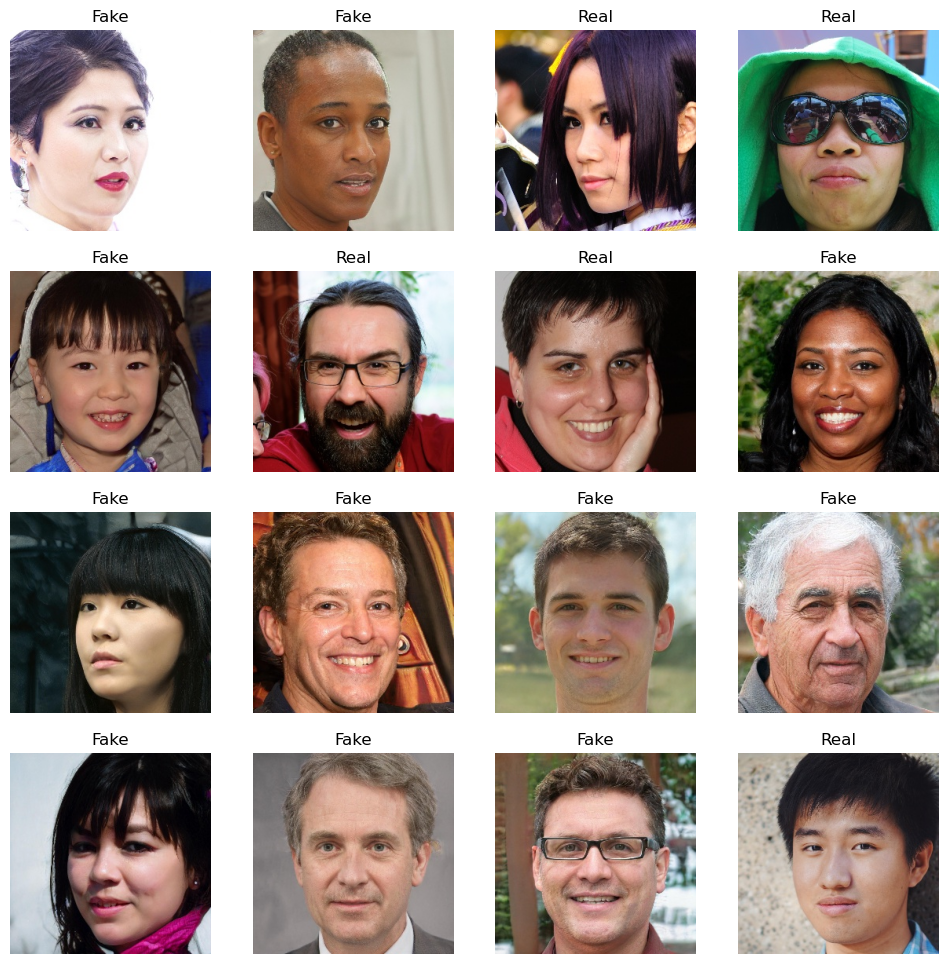

In [118]:
img,lbl = next(train_ds)
plot_images(img,lbl)


It's visible that all the value are scaled.

In [119]:
for img, label in train_ds:
    print("Values: ", img[0])
    print("Label: ", label[0])
    break

Values:  [[[0.6666667  0.65882355 0.6117647 ]
  [0.65882355 0.6509804  0.6039216 ]
  [0.64705884 0.6392157  0.5921569 ]
  ...
  [0.58431375 0.5411765  0.43137258]
  [0.59607846 0.54901963 0.44705886]
  [0.6039216  0.5568628  0.454902  ]]

 [[0.6509804  0.6431373  0.59607846]
  [0.64705884 0.6392157  0.5921569 ]
  [0.6431373  0.63529414 0.5882353 ]
  ...
  [0.5803922  0.5372549  0.427451  ]
  [0.5882353  0.5411765  0.43921572]
  [0.5921569  0.54509807 0.4431373 ]]

 [[0.6392157  0.62352943 0.5803922 ]
  [0.6392157  0.62352943 0.5803922 ]
  [0.6392157  0.62352943 0.5803922 ]
  ...
  [0.5921569  0.5372549  0.43137258]
  [0.5921569  0.5372549  0.43529415]
  [0.5882353  0.53333336 0.43137258]]

 ...

 [[0.89019614 0.7803922  0.5921569 ]
  [0.85098046 0.7411765  0.5529412 ]
  [0.8352942  0.7254902  0.5372549 ]
  ...
  [0.7725491  0.72156864 0.65882355]
  [0.7803922  0.7372549  0.6666667 ]
  [0.77647066 0.73333335 0.654902  ]]

 [[0.8470589  0.7372549  0.5411765 ]
  [0.8588236  0.7490196  0.5

Let's print the input shape:
- 32 is the batch size
- 256s are the pixel's values.
- 3 are the channel (rgb)

In [120]:
for img, label in train_ds:
    print(img.shape)
    print(label.shape)
    break

(64, 256, 256, 3)
(64,)


In [121]:
train_ds.class_indices

{'fake': 0, 'real': 1}

# CNN model architecture (DenseNet121)

In [122]:
input_shape = (256, 256, 3) #define the input shape of our data

In [123]:
"""#create the model's architecture and compile it
def get_model(input_shape):

    input = tf.keras.Input(shape=input_shape)

    densenet = tf.keras.applications.DenseNet121( weights="imagenet", include_top=False, input_tensor = input)

    x = tf.keras.layers.GlobalAveragePooling2D()(densenet.output)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    output = tf.keras.layers.Dense(1, activation='sigmoid')(x) #binary classification

    model = tf.keras.Model(densenet.input, output)

    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

    return model"""


'#create the model\'s architecture and compile it\ndef get_model(input_shape):\n\n    input = tf.keras.Input(shape=input_shape)\n\n    densenet = tf.keras.applications.DenseNet121( weights="imagenet", include_top=False, input_tensor = input)\n\n    x = tf.keras.layers.GlobalAveragePooling2D()(densenet.output)\n    x = tf.keras.layers.Dense(512, activation=\'relu\')(x)\n    x = tf.keras.layers.BatchNormalization()(x)\n    x = tf.keras.layers.Dropout(0.3)(x)\n    output = tf.keras.layers.Dense(1, activation=\'sigmoid\')(x) #binary classification\n\n    model = tf.keras.Model(densenet.input, output)\n\n    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])\n\n    return model'

In [128]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense,Conv2D, BatchNormalization, Dropout,Activation

def get_model(input_shape, learning_rate=1e-4): # LR disarankan lebih rendah
    
    # 1. Definisikan Input Tensor
    input = tf.keras.Input(shape=input_shape)
    
    # 2. Muat Base Model (MobileNetV2)
    base_model = MobileNetV2(
        weights="imagenet", 
        include_top=False, 
        input_tensor=input # Menghubungkan input layer ke base model
    )
    
    # Kunci (Freeze) semua bobot Base Model
    base_model.trainable = False 
    
    # Pastikan data melewati model dalam mode inferensi saat base model dibekukan
    x = base_model.output

    #  Lapisan Feature Extraction Kustom (Conv2D setelah 7x7 output)
    x = Conv2D(512, (7, 7), padding='same', name='custom_conv')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    # 3. Custom Head (Lapisan Klasifikasi)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x) # Binary classification

    # 4. Buat dan Kompilasi Model
    model = tf.keras.Model(inputs=base_model.input, outputs=output)

    # Gunakan Learning Rate yang lebih rendah untuk stabilitas
    model.compile(
        loss="binary_crossentropy", 
        optimizer=Adam(learning_rate=learning_rate), 
        metrics=["accuracy"]
    )

    return model

# Contoh penggunaan:
# model = get_model(input_shape=(224, 224, 3))

### model_ft = get_model(input_shape)

#model_ft.summary()

In [ ]:
#tf.keras.utils.plot_model(model_ft, show_shapes=True)

Let's define the Callbacks

**ModelCheckpoint** callback is used in conjunction with training using model.fit() to save a model or weights (in a checkpoint file) at some interval, so the model or weights can be loaded later to continue the training from the state saved.
In this case, we don't have to worry about training for too long and overfitting the training set.

In [130]:
checkpoint_filepath = "model_cp.h5"

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    mode='min', #minimize the loss value
    save_best_only=True)

The **EarlyStopping** callback stops training when a monitored metric (in this case val_loss) has stopped improving (in this case decreasing).

In [131]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                     patience=5,
                                                     restore_best_weights=True,
                                                    )

**ReduceOnPlateau** callback reduces learning rate when a metric has stopped improving. Models often benefit from reducing the learning rate by a factor of 2-10 once learning stagnates. This callback monitors a quantity and if no improvement is seen for a 'patience' number of epochs, the learning rate is reduced.

In [132]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                 factor=0.2,
                                                 patience=3)

# Training

In [133]:
history_ft = model_ft.fit(train_ds,
                       epochs = 50,
                       validation_data = valid_ds,
                       callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr])

Epoch 1/50
313/313 [==============================] - 90s 268ms/step - loss: 0.5043 - accuracy: 0.7713 - val_loss: 0.4490 - val_accuracy: 0.7975 - lr: 1.0000e-04
Epoch 2/50
313/313 [==============================] - 79s 250ms/step - loss: 0.3551 - accuracy: 0.8468 - val_loss: 0.3757 - val_accuracy: 0.8350 - lr: 1.0000e-04
Epoch 3/50
313/313 [==============================] - 79s 253ms/step - loss: 0.2956 - accuracy: 0.8712 - val_loss: 0.3343 - val_accuracy: 0.8435 - lr: 1.0000e-04
Epoch 4/50
313/313 [==============================] - 80s 255ms/step - loss: 0.2483 - accuracy: 0.8959 - val_loss: 0.3649 - val_accuracy: 0.8525 - lr: 1.0000e-04
Epoch 5/50
313/313 [==============================] - 78s 249ms/step - loss: 0.2082 - accuracy: 0.9129 - val_loss: 0.4288 - val_accuracy: 0.8365 - lr: 1.0000e-04
Epoch 6/50
313/313 [==============================] - 77s 246ms/step - loss: 0.1746 - accuracy: 0.9316 - val_loss: 0.4310 - val_accuracy: 0.8390 - lr: 1.0000e-04
Epoch 7/50
313/313 [========

# Results

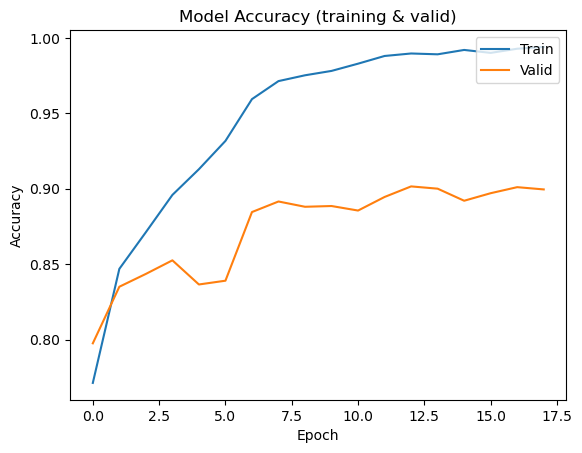

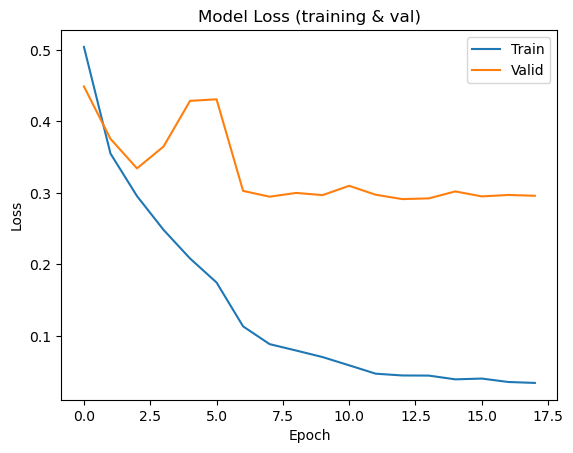

In [134]:
plt.plot(history_ft.history['accuracy'])
plt.plot(history_ft.history['val_accuracy'])
plt.title('Model Accuracy (training & valid)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Valid'], loc='upper right')
plt.show()


plt.plot(history_ft.history['loss'])
plt.plot(history_ft.history['val_loss'])
plt.title('Model Loss (training & val)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Valid'], loc='upper right')
plt.show()

The model is clearly overfitted. So wee have to restore the model weights from the ModelCheckpoint callback.

Let's try to evaluate the full overfitted model. We can see that it has a poor performance.

In [135]:
# Evaluate the model on the test set
test_loss, test_acc = model_ft.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

32/32 [==============================] - 8s 259ms/step - loss: 0.2857 - accuracy: 0.8935
Test Loss: 0.2856951057910919
Test Accuracy: 0.8934999704360962


Here a ModelCheckpoint callback is necessary. Indeed loading the best weights results in a much better performance on the test set.

In [137]:
model = get_model(input_shape)

# Restore the weights
model.load_weights('model_cp.h5')


In [ ]:
"""from google.colab import drive
drive.mount('/content/drive')"""

In [138]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

32/32 [==============================] - 10s 248ms/step - loss: 0.2857 - accuracy: 0.8935
Test Loss: 0.2856951057910919
Test Accuracy: 0.8934999704360962


# Image example - Qualitative results

Let's try the model on a real image. It is very confident (99.96%) that it is a real one.

In [ ]:
#real example
test_image = tf.keras.preprocessing.image.load_img('/kaggle/input/real-fake-22k/real-vs-fake10k/test/real/00053.jpg', target_size=(256, 256, 3))
plt.imshow(test_image)


test_image_arr = tf.keras.preprocessing.image.img_to_array(test_image)
test_image_arr = np.expand_dims(test_image, axis=0)
test_image_arr = test_image_arr/255.


result = model.predict(test_image_arr)

plt.title(f"This image is {100 * (1 - result[0][0]):.2f}% Fake and {100 * result[0][0]:.2f}% Real.")


The result score is near 1 if the image is **real** and 0 if the image is **fake**.

In [ ]:
test_image = tf.keras.preprocessing.image.load_img('/kaggle/input/real-fake-22k/real-vs-fake10k/test/fake/00V5CZZSSO.jpg', target_size=(256, 256, 3))
plt.imshow(test_image)

#fake example
test_image_arr = tf.keras.preprocessing.image.img_to_array(test_image)
test_image_arr = np.expand_dims(test_image, axis=0)
test_image_arr = test_image_arr/255.


result = model.predict(test_image_arr)

plt.title(f"This image is {100 * (1 - result[0][0]):.2f}% Fake and {100 * result[0][0]:.2f}% Real.")

# Quantitative results

32/32 [==============================] - 10s 283ms/step


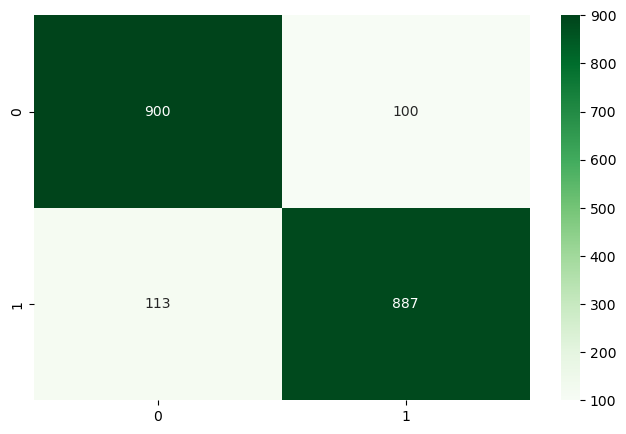

0.8935

In [140]:
# Assuming you have defined your model as 'model'
predicted_labels = model.predict(test_ds)
true_labels = test_ds.classes
plt.figure(figsize = (8,5))
sns.heatmap(metrics.confusion_matrix(true_labels, predicted_labels.round()), annot = True,fmt="d",cmap = "Greens")
plt.show()
metrics.accuracy_score(true_labels, predicted_labels.round())

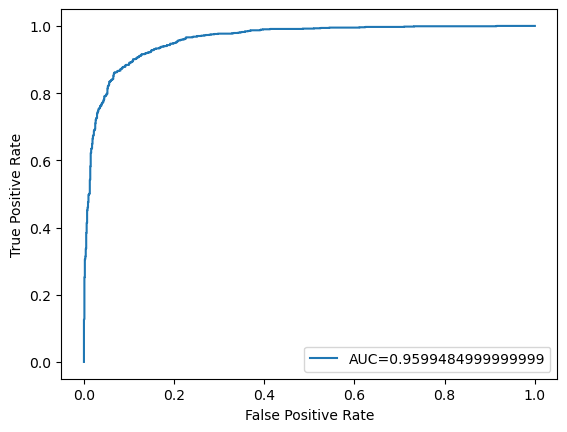

In [141]:
fpr, tpr, _ = metrics.roc_curve(true_labels,  predicted_labels)
auc = metrics.roc_auc_score(true_labels, predicted_labels)

#create ROC curve
plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()

# Grad-cam class activation visualization

# Grad-CAM Explains Why

In [ ]:
save_and_display_gradcam(img_path, heatmap)
save_and_display_gradcam(img_path, heatmap_2)
save_and_display_gradcam(img_path, heatmap_3)
save_and_display_gradcam(img_path, heatmap_4)
save_and_display_gradcam(img_path, heatmap_5)

# CNN model architecture Unfreeze

To be continued.

In [149]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense,Conv2D, BatchNormalization, Dropout,Activation

def get_model(input_shape, learning_rate, unfreeze_percentage=0.0):
    """
    Membangun model MobileNetV2 dengan Custom Head.
    Mengontrol persentase lapisan Base Model yang dibuka (unfreeze)
    dari lapisan teratas (top layers).
    """
    
    # 1. Definisikan Input Tensor
    input = tf.keras.Input(shape=input_shape)
    
    # 2. Muat Base Model (MobileNetV2)
    base_model = MobileNetV2(
        weights="imagenet", 
        include_top=False, 
        input_tensor=input
    )
    
    # --- LOGIKA KONTROL UNFREEZE ---

    # Default: Semua lapisan Base Model dibekukan (freeze)
    base_model.trainable = False 
    
    total_layers = len(base_model.layers)
    
    if unfreeze_percentage > 0.0:
        # Hitung jumlah lapisan yang akan dibuka (unfreeze)
        num_unfreeze = int(total_layers * unfreeze_percentage)
        
        # Buka lapisan dari lapisan PALING ATAS (lapisan terakhir dalam list)
        for layer in base_model.layers[-num_unfreeze:]:
            layer.trainable = True # Mengatur lapisan yang ditargetkan agar dapat dilatih
        
        print(f"Base Model: {num_unfreeze} dari {total_layers} lapisan dibuka ({unfreeze_percentage*100:.0f}% Unfreeze).")
    else:
        print(f"Base Model: Semua lapisan dibekukan (Freeze Penuh).")
    
    # ----------------------------------------
    
    x = base_model.output

    # Lapisan Feature Extraction Kustom (Custom Conv)
    # Ini selalu trainable karena tidak termasuk dalam base_model
    x = Conv2D(512, (7, 7), padding='same', name='custom_conv')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    # 3. Custom Head (Lapisan Klasifikasi)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x) 

    # 4. Buat dan Kompilasi Model
    model = tf.keras.Model(inputs=base_model.input, outputs=output)

    # Re-compile model dengan LR yang dispesifikasikan
    model.compile(
        loss="binary_crossentropy", 
        optimizer=Adam(learning_rate=learning_rate), 
        metrics=["accuracy"]
    )

    return model

In [150]:
# Contoh Tahap 2: Fine-Tuning 50%
model_ft_50 = get_model(
    input_shape=(224, 224, 3), 
    learning_rate=1e-5, # Wajib LR sangat rendah!
    unfreeze_percentage=0.50
)

# Muat bobot terbaik dari Tahap 1 ke model_ft_50 di sini
# model_ft_50.load_weights('best_head_weights.h5') 

# Lanjutkan pelatihan dengan LR 1e-5
checkpoint_filepath = "model_half_unfreeze_cp.h5"



Base Model: 77 dari 154 lapisan dibuka (50% Unfreeze).


In [151]:
history_ft = model_ft_50.fit(train_ds,
                       epochs = 50,
                       validation_data = valid_ds,
                       callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr])

Epoch 1/50
313/313 [==============================] - 120s 332ms/step - loss: 0.4715 - accuracy: 0.7856 - val_loss: 1.2086 - val_accuracy: 0.5240 - lr: 1.0000e-05
Epoch 2/50
313/313 [==============================] - 97s 309ms/step - loss: 0.2697 - accuracy: 0.8871 - val_loss: 0.9990 - val_accuracy: 0.6480 - lr: 1.0000e-05
Epoch 3/50
313/313 [==============================] - 96s 306ms/step - loss: 0.1767 - accuracy: 0.9293 - val_loss: 0.9754 - val_accuracy: 0.6885 - lr: 1.0000e-05
Epoch 4/50
313/313 [==============================] - 107s 342ms/step - loss: 0.1210 - accuracy: 0.9566 - val_loss: 0.5022 - val_accuracy: 0.8185 - lr: 1.0000e-05
Epoch 5/50
313/313 [==============================] - 101s 322ms/step - loss: 0.0869 - accuracy: 0.9686 - val_loss: 0.2650 - val_accuracy: 0.9040 - lr: 1.0000e-05
Epoch 6/50
313/313 [==============================] - 122s 389ms/step - loss: 0.0623 - accuracy: 0.9789 - val_loss: 0.3405 - val_accuracy: 0.8870 - lr: 1.0000e-05
Epoch 7/50
313/313 [====

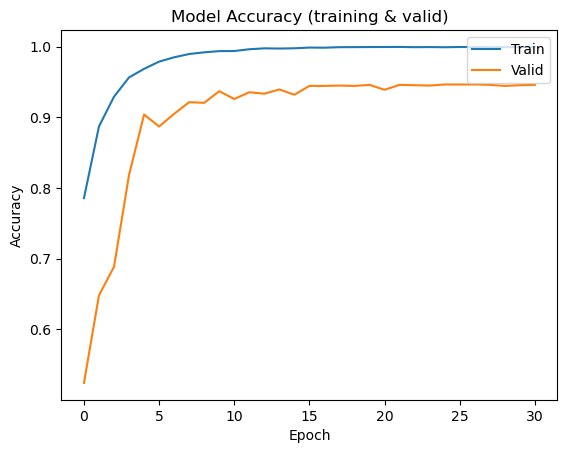

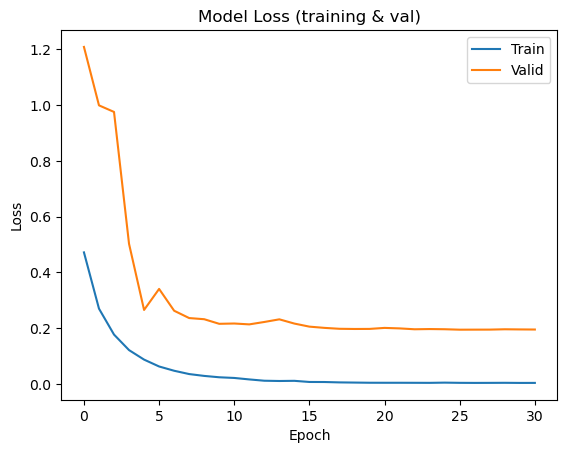

In [152]:
plt.plot(history_ft.history['accuracy'])
plt.plot(history_ft.history['val_accuracy'])
plt.title('Model Accuracy (training & valid)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Valid'], loc='upper right')
plt.show()


plt.plot(history_ft.history['loss'])
plt.plot(history_ft.history['val_loss'])
plt.title('Model Loss (training & val)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Valid'], loc='upper right')
plt.show()

In [154]:
# Evaluate the model on the test set
test_loss, test_acc = model_ft_50.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

32/32 [==============================] - 7s 212ms/step - loss: 0.1967 - accuracy: 0.9345
Test Loss: 0.19667771458625793
Test Accuracy: 0.934499979019165


32/32 [==============================] - 9s 265ms/step


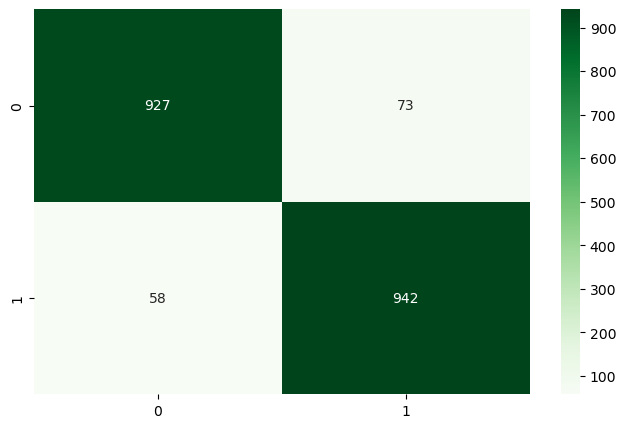

0.9345

In [156]:
# Assuming you have defined your model as 'model'
predicted_labels = model_ft_50.predict(test_ds)
true_labels = test_ds.classes
plt.figure(figsize = (8,5))
sns.heatmap(metrics.confusion_matrix(true_labels, predicted_labels.round()), annot = True,fmt="d",cmap = "Greens")
plt.show()
metrics.accuracy_score(true_labels, predicted_labels.round())

# END :)